# Chronic Kidney Disease Prediction using Decision Tree

## Problem Statement

The objective of this project is to predict whether a patient has Chronic Kidney Disease (CKD) using clinical and laboratory data. A Decision Tree Classifier is used to classify patients, and feature importance is analyzed to identify the most significant medical parameters affecting CKD prediction.

# Import Libraries

In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [17]:
data = pd.read_csv('kidney_Disease.csv')

# Data Understanding

In [18]:
data.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [19]:
data.tail()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd
399,399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,53,6800,6.1,no,no,no,good,no,no,notckd


In [20]:
data.sample(5)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
74,74,56.0,90.0,1.015,2.0,0.0,abnormal,abnormal,notpresent,notpresent,...,29,6400,3.4,yes,no,no,good,no,no,ckd
180,180,73.0,90.0,1.010,1.0,4.0,abnormal,abnormal,present,notpresent,...,28,NaN,NaN,no,yes,no,good,no,no,ckd
336,336,25.0,60.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,40,9200,5.2,no,no,no,good,no,no,notckd
272,272,56.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,42,5600,5.5,no,no,no,good,no,no,notckd
256,256,60.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,41,10700,5.1,no,no,no,good,no,no,notckd


In [21]:
data.shape

(400, 26)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

# Feature and Target Separation

In [23]:
# Features and Target

x = data.drop(['id', 'classification'], axis=1)

y = data['classification']

print("Features Shape:", x.shape)
print("Target Shape:", y.shape)

Features Shape: (400, 24)
Target Shape: (400,)


# Exploratory Data Analysis (EDA)

In [24]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     330 non-null    object 
 16  wc      295 non-null    object 
 17  rc      270 non-null    object 
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

In [25]:
x.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [26]:
x.shape

(400, 24)

In [27]:
x.isnull().sum()

age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       70
wc       105
rc       130
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64

### Target Variable Distribution

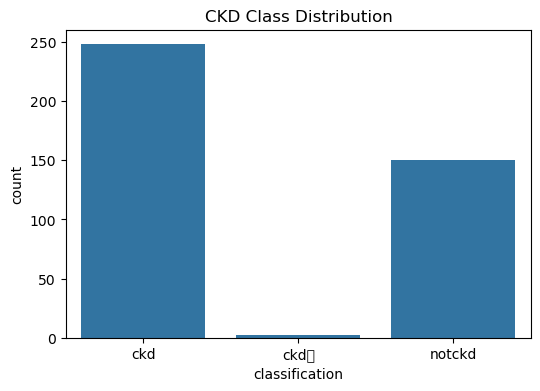

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("CKD Class Distribution")

plt.show()

### Histograms

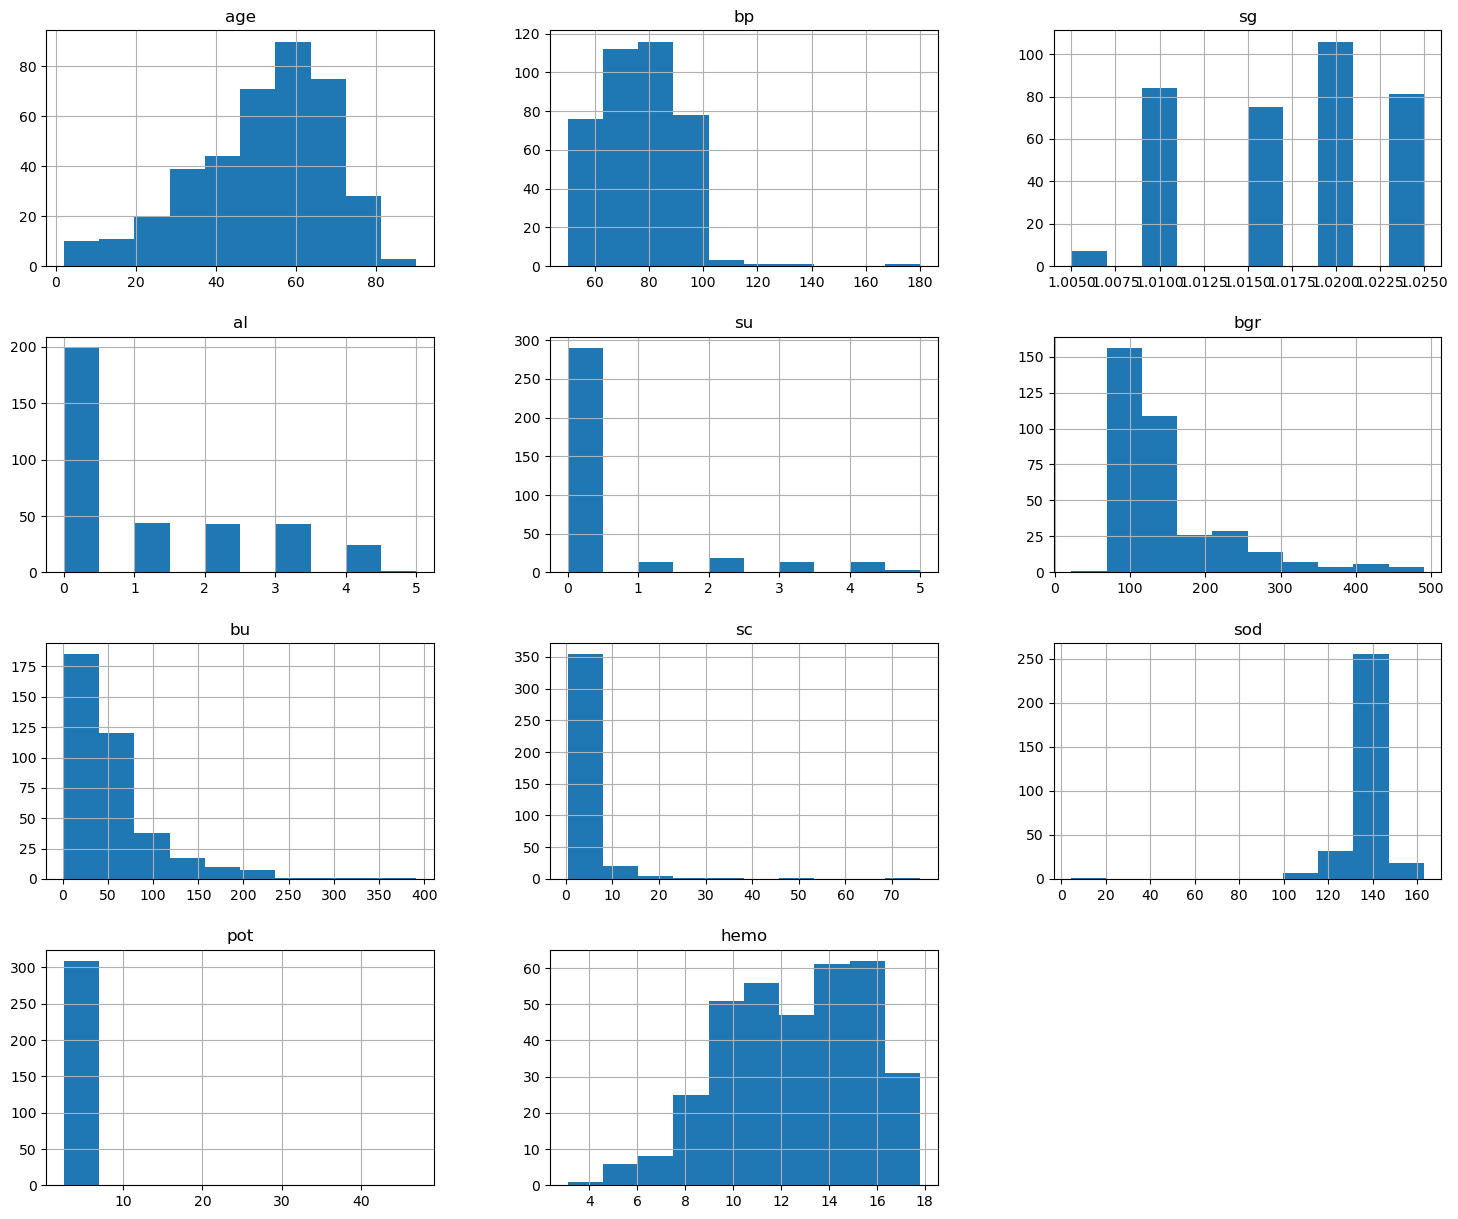

In [30]:
x.hist(figsize = (18,15))
plt.show()

### Boxplots

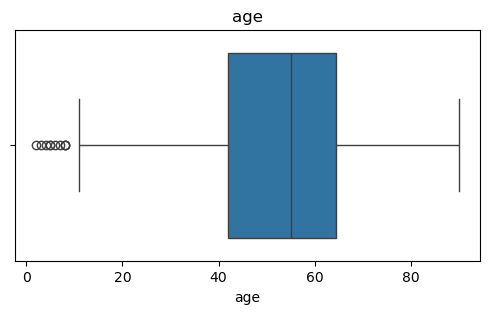

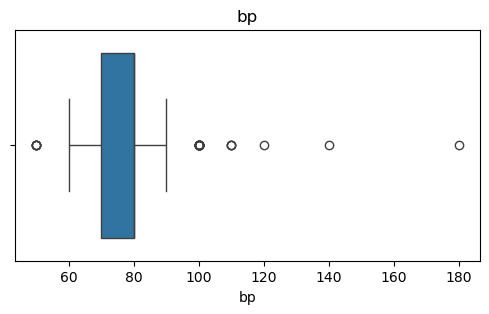

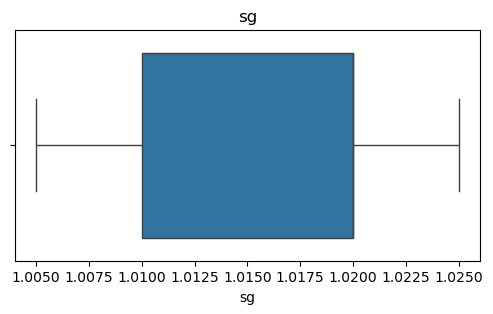

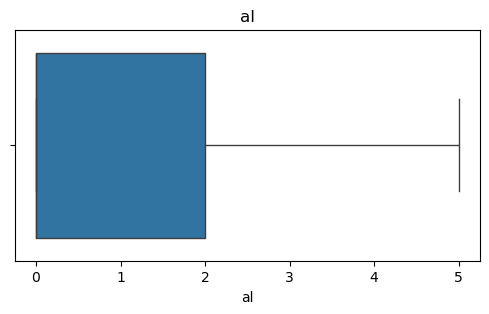

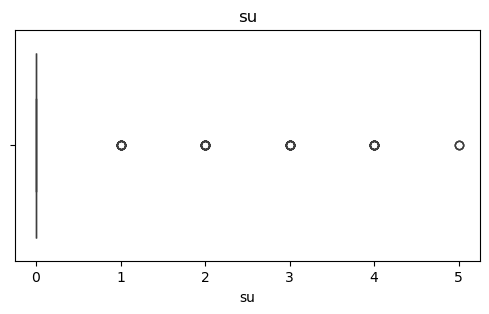

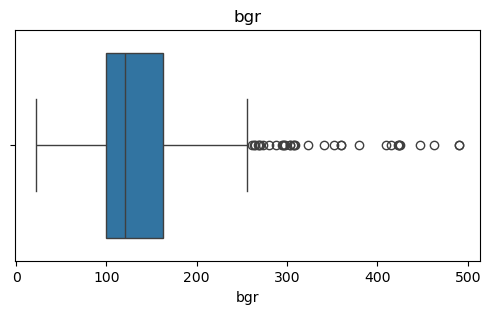

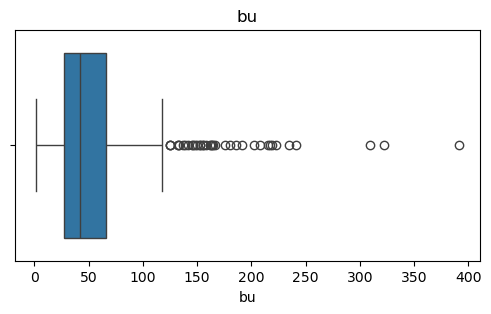

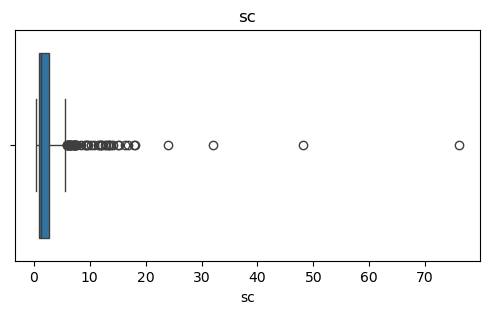

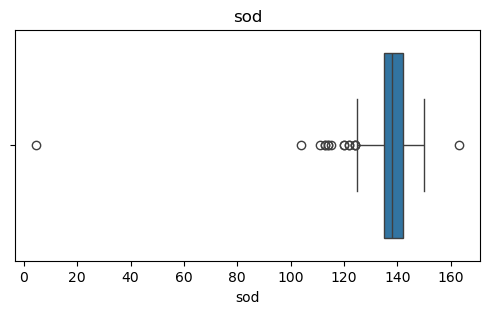

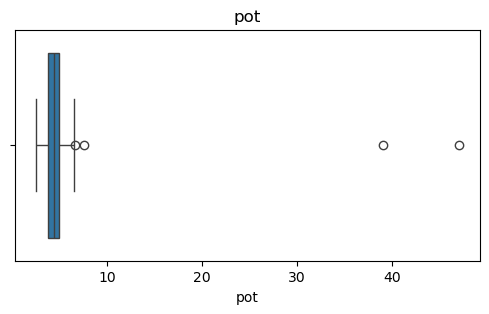

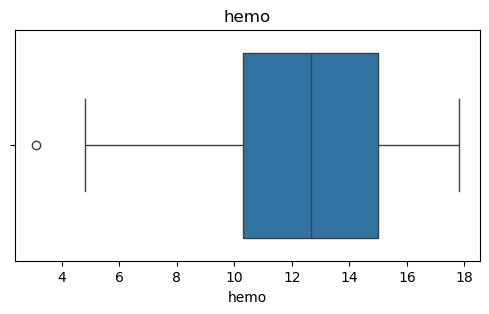

In [31]:
num_cols = x.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=x[col])
    plt.title(col)
    plt.show()

# Data Preprocessing

## Missing Value Imputation

In [32]:
median_imputer = SimpleImputer(strategy = "median")
mode_imputer = SimpleImputer(strategy = "most_frequent")

In [33]:
cat_data = x.select_dtypes(include = ['object']).columns
num_data = x.select_dtypes(include = ['int64','float64']).columns

In [34]:
for fea in cat_data:
    x[[fea]] = mode_imputer.fit_transform(x[[fea]])

for fea in num_data:
    x[[fea]] = median_imputer.fit_transform(x[[fea]])

In [35]:
x.isnull().sum()

age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wc       0
rc       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
dtype: int64

## Label Encoding

In [36]:
le = LabelEncoder()

In [37]:
# Encoding features
for fea in cat_data:
    x[fea] = le.fit_transform(x[fea])

In [38]:
# Encode Target Variable
y = y.str.strip()

y = y.map({'ckd':0,'notckd':1})

### Correlation Heatmap

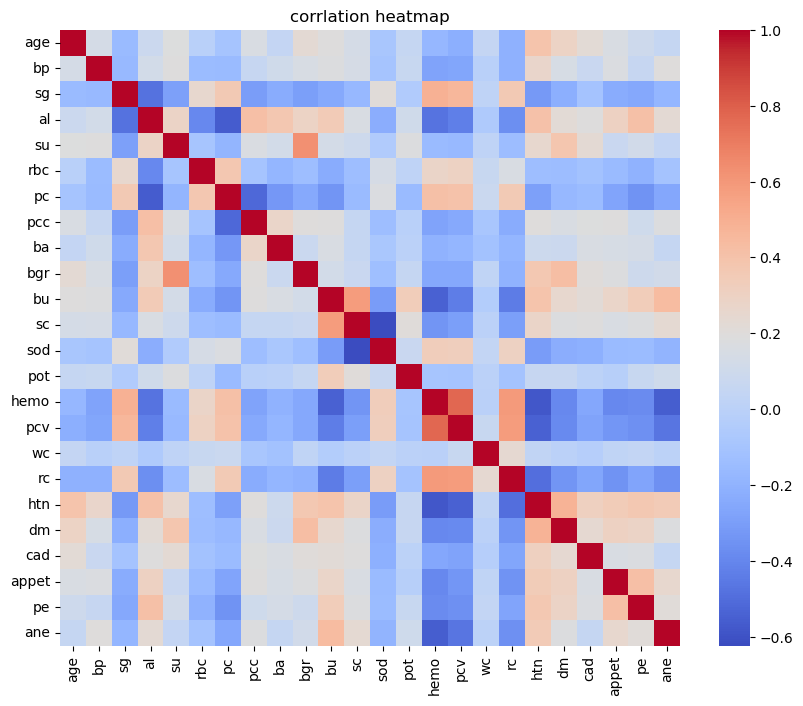

In [62]:
plt.figure(figsize = (10,8))
sns.heatmap(x.corr() , cmap = 'coolwarm')
plt.title("corrlation heatmap")
plt.show()

# Train-Test Split

In [39]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Decision Tree Model (All Features)

In [40]:
dt_all = DecisionTreeClassifier(random_state=42)

In [41]:
dt_all.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
# Prediction
y_pred = dt_all.predict(x_test)

In [43]:
# Model Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")

print(classification_report(y_test, y_pred))

Accuracy : 0.9875

Confusion Matrix
[[51  1]
 [ 0 28]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        52
           1       0.97      1.00      0.98        28

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



# Feature Importance

In [44]:
feature_importance = pd.DataFrame({

    "Feature": x.columns,

    "Importance": dt_all.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
14,hemo,0.697126
2,sg,0.199937
3,al,0.026045
10,bu,0.018022
17,rc,0.016242
15,pcv,0.015897
1,bp,0.015897
12,sod,0.008831
11,sc,0.002003
22,pe,0.000000


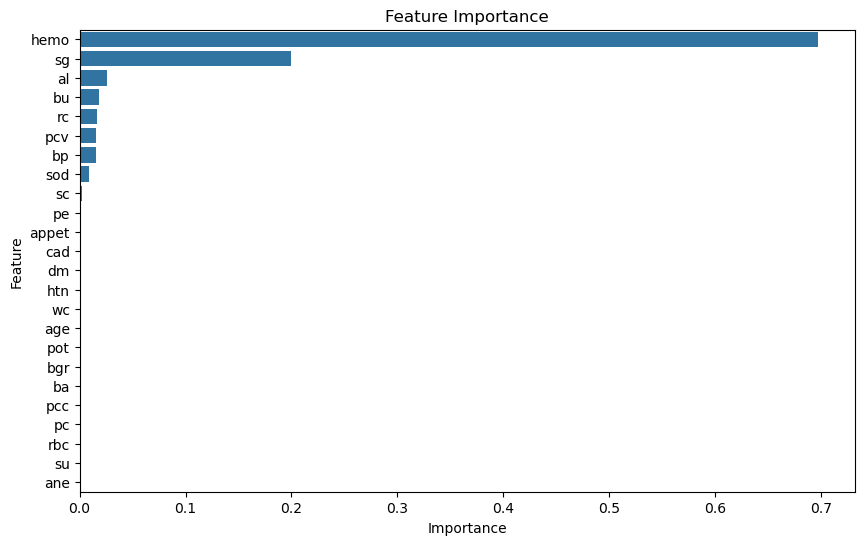

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

# Decision Tree using Top Features (>0.01)

In [46]:
selected_features = feature_importance[
    feature_importance["Importance"] > 0.01
]["Feature"]

X_selected = x[selected_features]

In [47]:
x_train, x_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
dt_selected = DecisionTreeClassifier(random_state=42)

In [49]:
dt_selected.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:
y_pred_selected = dt_selected.predict(x_test)

In [51]:
print("Accuracy :", accuracy_score(y_test, y_pred_selected))

Accuracy : 0.975


# Decision Tree using Top 5 Features

In [52]:
top5_features = [
    "hemo",
    "sg",
    "al",
    "bu",
    "rc"
]

X_top5 = x[top5_features]

In [53]:
X_top5

,hemo,sg,al,bu,rc
0,15.4,1.020,1.0,36.0,34
1,11.3,1.020,4.0,18.0,34
2,9.6,1.010,2.0,53.0,34
3,11.2,1.005,4.0,56.0,19
4,11.6,1.010,2.0,26.0,27
...,...,...,...,...,...
395,15.7,1.020,0.0,49.0,30
396,16.5,1.025,0.0,31.0,44
397,15.8,1.020,0.0,26.0,36
398,14.2,1.025,0.0,50.0,41


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_top5,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
dt_top5 = DecisionTreeClassifier(random_state=42)

In [56]:
dt_top5.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [57]:
y_pred_top5 = dt_top5.predict(X_test)

In [58]:
print("Accuracy :", accuracy_score(y_test, y_pred_top5))

Accuracy : 0.9875


# Model Comparison

In [59]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree (All Features)",
        "Decision Tree (Selected Features)",
        "Decision Tree (Top 5 Features)"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_selected),
        accuracy_score(y_test, y_pred_top5)
    ]

})

comparison

,Model,Accuracy
0,Decision Tree (All Features),0.9875
1,Decision Tree (Selected Features),0.9750
2,Decision Tree (Top 5 Features),0.9875


# Save Model

In [60]:
import joblib

joblib.dump(dt_top5, "ckd_model.pkl")

['ckd_model.pkl']

# Conclusion

• Built a Decision Tree classifier to predict Chronic Kidney Disease.

• Performed data cleaning, missing value imputation, and label encoding.

• Used Decision Tree feature importance to identify the most significant predictors.

• Compared models using all features, selected features, and the top 5 features.

• The Top 5 Features model achieved the best accuracy of 98.75%, making it the final model.